In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

In [46]:
def llm_call(state):
    return {"messages": model.invoke(state["messages"])}

def trim_node(state):
    remove_msg = [RemoveMessage(id = m.id) for m in state["messages"][:-4]]
    return {"messages": remove_msg}

# from langchain_core.messages import RemoveMessage
# def llm_call(state):
#     remove_msg = [RemoveMessage(id=i.id) for i in state["messages"][:-4]]
#     return_msg = model.invoke(state["messages"])
#     remove_msg.append(return_msg)
#     return {"messages":remove_msg}

In [47]:
graph = StateGraph(MessagesState)

graph.add_node("llm_call", llm_call)
graph.add_node("trim_node", trim_node)
graph.add_edge(START, "trim_node")
graph.add_edge("trim_node","llm_call")
graph.add_edge("llm_call",END)

wf = graph.compile()



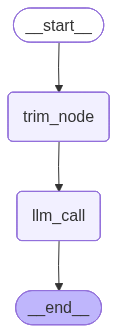

In [48]:
wf

In [ ]:
# from langchain_core.messages import HumanMessage
# msg_state = [HumanMessage(content = "Sum of 3 and 4 is")]

In [55]:
final_state = wf.invoke({"messages":"sum of 3 and 4 is "})
# ai_msg = final_state["messages"][1]
# msg_state.append(ai_msg)
for i in final_state["messages"]:
    i.pretty_print()

================================ Human Message =================================

sum of 3 and 4 is 
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [56]:
type(final_state["messages"])

list

In [57]:
final_state['messages'].append(HumanMessage("multiply 7 with the result", id = 3))
final_state

{'messages': [HumanMessage(content='sum of 3 and 4 is ', additional_kwargs={}, response_metadata={}, id='6b5fe7a2-3124-4a55-853b-4a1661506cc9'),
  AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--5067b0a1-d4fc-4fac-bb0c-b967b9277116-0'),
  HumanMessage(content='multiply 7 with the result', additional_kwargs={}, response_metadata={}, id='3')]}

In [58]:
final_state = wf.invoke({"messages":final_state["messages"]})
for i in final_state["messages"]:
    i.pretty_print()

================================ Human Message =================================

sum of 3 and 4 is 
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

multiply 7 with the result
================================== Ai Message ==================================

The result we're referring to is the sum of 3 and 4, which is 7.

Multiplying 7 by 7 gives us:

7 * 7 = 49

So the answer is **49**.


In [59]:
final_state['messages'].append(HumanMessage("are you a great methametician ah ?", id = 5))
final_state

{'messages': [HumanMessage(content='sum of 3 and 4 is ', additional_kwargs={}, response_metadata={}, id='6b5fe7a2-3124-4a55-853b-4a1661506cc9'),
  AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--5067b0a1-d4fc-4fac-bb0c-b967b9277116-0'),
  HumanMessage(content='multiply 7 with the result', additional_kwargs={}, response_metadata={}, id='3'),
  AIMessage(content="The result we're referring to is the sum of 3 and 4, which is 7.\n\nMultiplying 7 by 7 gives us:\n\n7 * 7 = 49\n\nSo the answer is **49**.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--a797508c-e08a-463c-bd70-8745d4e683c8-0'),
  HumanMessage(content='are you a great methametician ah ?', additi

In [60]:
final_state = wf.invoke({"messages":final_state["messages"]})
for i in final_state["messages"]:
    i.pretty_print()

================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

multiply 7 with the result
================================== Ai Message ==================================

The result we're referring to is the sum of 3 and 4, which is 7.

Multiplying 7 by 7 gives us:

7 * 7 = 49

So the answer is **49**.
================================ Human Message =================================

are you a great methametician ah ?
================================== Ai Message ==================================

I am a large language model, trained on a massive dataset of text and code. While I can perform mathematical calculations and solve problems, I wouldn't describe myself as a "great mathematician" in the same way as a human mathematician who develops new theories, proofs, or algorithms.

Think of me as a powerful calculator and encyclopedia of mathematical knowledge. I

In [61]:
final_state['messages'].append(HumanMessage("greatnews okay bbye", id = 6))
final_state

{'messages': [AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--5067b0a1-d4fc-4fac-bb0c-b967b9277116-0'),
  HumanMessage(content='multiply 7 with the result', additional_kwargs={}, response_metadata={}, id='3'),
  AIMessage(content="The result we're referring to is the sum of 3 and 4, which is 7.\n\nMultiplying 7 by 7 gives us:\n\n7 * 7 = 49\n\nSo the answer is **49**.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--a797508c-e08a-463c-bd70-8745d4e683c8-0'),
  HumanMessage(content='are you a great methametician ah ?', additional_kwargs={}, response_metadata={}, id='5'),
  AIMessage(content='I am a large language model, trained on a massive dataset of text

In [62]:
final_state = wf.invoke({"messages":final_state["messages"]})
for i in final_state["messages"]:
    i.pretty_print()

================================== Ai Message ==================================

The result we're referring to is the sum of 3 and 4, which is 7.

Multiplying 7 by 7 gives us:

7 * 7 = 49

So the answer is **49**.
================================ Human Message =================================

are you a great methametician ah ?
================================== Ai Message ==================================

I am a large language model, trained on a massive dataset of text and code. While I can perform mathematical calculations and solve problems, I wouldn't describe myself as a "great mathematician" in the same way as a human mathematician who develops new theories, proofs, or algorithms.

Think of me as a powerful calculator and encyclopedia of mathematical knowledge. I can access and process information very quickly, but I don't possess the same level of intuition, creativity, or deep understanding that a human mathematician has.

So, I'm a useful tool for mathematics, but not a m